In [2]:
import pandas as pd
df_changes = pd.read_csv("country_changes.csv")
print(df_changes)

    country_code  death_2000  death_2019  death_change      gdp_2000  \
0            ALB       5.619       7.473         1.854   1160.420471   
1            DZA       5.109       4.681        -0.428   1772.928691   
2            AND       6.228       5.560        -0.668  21810.250380   
3            AGO      18.080       7.701       -10.379    563.733796   
4            ATG       6.254       6.448         0.194  12027.494980   
..           ...         ...         ...           ...           ...   
177          UZB       7.006       5.970        -1.036    555.149231   
178          VUT       5.334       5.494         0.160   1460.238177   
179          VNM       5.486       6.300         0.814    404.029784   
180          PSE       4.500       3.134        -1.366   1476.171850   
181          ZMB      16.198       6.482        -9.716    359.429501   

         gdp_2019    gdp_change  health_2000  health_2019  health_change  \
0     6069.439031   4909.018560    65.476746   366.340149  

In [3]:
import pandas as pd 

df_levels = pd.read_csv("balanced_panel_features.csv")
print(df_levels)

    country_code        country_name  year  pop_65_plus  gdp_per_capita  \
0            ALB             Albania  2000     7.330691     1160.420471   
1            ALB             Albania  2019    14.248099     6069.439031   
2            DZA             Algeria  2000     4.383121     1772.928691   
3            DZA             Algeria  2019     5.774978     4468.453419   
4            AND             Andorra  2000    12.321687    21810.250380   
..           ...                 ...   ...          ...             ...   
359          VNM            Viet Nam  2019     7.250230     3440.900254   
360          PSE  West Bank and Gaza  2000     2.284161     1476.171850   
361          PSE  West Bank and Gaza  2019     3.505085     3656.858271   
362          ZMB              Zambia  2000     2.362280      359.429501   
363          ZMB              Zambia  2019     1.787009     1258.986198   

     current_health_expenditure_per_capita  death_rate   log_gdp  log_health  
0                   

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("country_changes.csv")

# Add log change variables if not already in your df
df["log_gdp_change"] = np.log(df["gdp_2019"]) - np.log(df["gdp_2000"])
df["log_health_change"] = np.log(df["health_2019"]) - np.log(df["health_2000"])

# Add region mapping
continent_map = {
    'AFG':'Asia','ALB':'Europe','DZA':'Africa','AGO':'Africa','ARG':'South America',
    'ARM':'Asia','AUS':'Oceania','AUT':'Europe','AZE':'Asia','BHS':'North America',
    'BHR':'Asia','BGD':'Asia','BLR':'Europe','BEL':'Europe','BLZ':'North America',
    'BEN':'Africa','BTN':'Asia','BOL':'South America','BIH':'Europe','BWA':'Africa',
    'BRA':'South America','BRN':'Asia','BGR':'Europe','BFA':'Africa','BDI':'Africa',
    'CPV':'Africa','KHM':'Asia','CMR':'Africa','CAN':'North America','CAF':'Africa',
    'TCD':'Africa','CHL':'South America','CHN':'Asia','COL':'South America',
    'COM':'Africa','COD':'Africa','COG':'Africa','CRI':'North America','CIV':'Africa',
    'HRV':'Europe','CUB':'North America','CYP':'Europe','CZE':'Europe','DNK':'Europe',
    'DJI':'Africa','DOM':'North America','ECU':'South America','EGY':'Africa',
    'SLV':'North America','GNQ':'Africa','ERI':'Africa','EST':'Europe','SWZ':'Africa',
    'ETH':'Africa','FJI':'Oceania','FIN':'Europe','FRA':'Europe','GAB':'Africa',
    'GMB':'Africa','GEO':'Asia','DEU':'Europe','GHA':'Africa','GRC':'Europe',
    'GTM':'North America','GIN':'Africa','GNB':'Africa','GUY':'South America',
    'HTI':'North America','HND':'North America','HUN':'Europe','ISL':'Europe',
    'IND':'Asia','IDN':'Asia','IRN':'Asia','IRQ':'Asia','IRL':'Europe','ISR':'Asia',
    'ITA':'Europe','JAM':'North America','JPN':'Asia','JOR':'Asia','KAZ':'Asia',
    'KEN':'Africa','KWT':'Asia','KGZ':'Asia','LAO':'Asia','LVA':'Europe',
    'LBN':'Asia','LSO':'Africa','LBR':'Africa','LBY':'Africa','LTU':'Europe',
    'LUX':'Europe','MDG':'Africa','MWI':'Africa','MYS':'Asia','MDV':'Asia',
    'MLI':'Africa','MLT':'Europe','MRT':'Africa','MUS':'Africa','MEX':'North America',
    'MDA':'Europe','MNG':'Asia','MNE':'Europe','MAR':'Africa','MOZ':'Africa',
    'MMR':'Asia','NAM':'Africa','NPL':'Asia','NLD':'Europe','NZL':'Oceania',
    'NIC':'North America','NER':'Africa','NGA':'Africa','MKD':'Europe','NOR':'Europe',
    'OMN':'Asia','PAK':'Asia','PAN':'North America','PNG':'Oceania','PRY':'South America',
    'PER':'South America','PHL':'Asia','POL':'Europe','PRT':'Europe','QAT':'Asia',
    'ROU':'Europe','RUS':'Europe','RWA':'Africa','SAU':'Asia','SEN':'Africa',
    'SRB':'Europe','SLE':'Africa','SGP':'Asia','SVK':'Europe','SVN':'Europe',
    'SOM':'Africa','ZAF':'Africa','KOR':'Asia','ESP':'Europe','LKA':'Asia',
    'SDN':'Africa','SUR':'South America','SWE':'Europe','CHE':'Europe','SYR':'Asia',
    'TWN':'Asia','TJK':'Asia','TZA':'Africa','THA':'Asia','TLS':'Asia',
    'TGO':'Africa','TTO':'North America','TUN':'Africa','TUR':'Asia','TKM':'Asia',
    'UGA':'Africa','UKR':'Europe','ARE':'Asia','GBR':'Europe','USA':'North America',
    'URY':'South America','UZB':'Asia','VEN':'South America','VNM':'Asia',
    'YEM':'Asia','ZMB':'Africa','ZWE':'Africa'
}

extra_map = {
    'AND': 'Europe', 'MCO': 'Europe', 'SMR': 'Europe',
    'ATG': 'North America', 'BRB': 'North America', 'DMA': 'North America',
    'GRD': 'North America', 'KNA': 'North America', 'LCA': 'North America',
    'VCT': 'North America', 'HTI': 'North America',
    'KIR': 'Oceania', 'MHL': 'Oceania', 'FSM': 'Oceania', 'NRU': 'Oceania',
    'PLW': 'Oceania', 'WSM': 'Oceania', 'SLB': 'Oceania', 'TON': 'Oceania',
    'TUV': 'Oceania', 'VUT': 'Oceania',
    'STP': 'Africa', 'SYC': 'Africa',
    'PSE': 'Asia'
}
continent_map.update(extra_map)
df["region"] = df["country_code"].map(continent_map).fillna("Unknown")
df["region"] = df["country_code"].map(continent_map).fillna("Unknown")

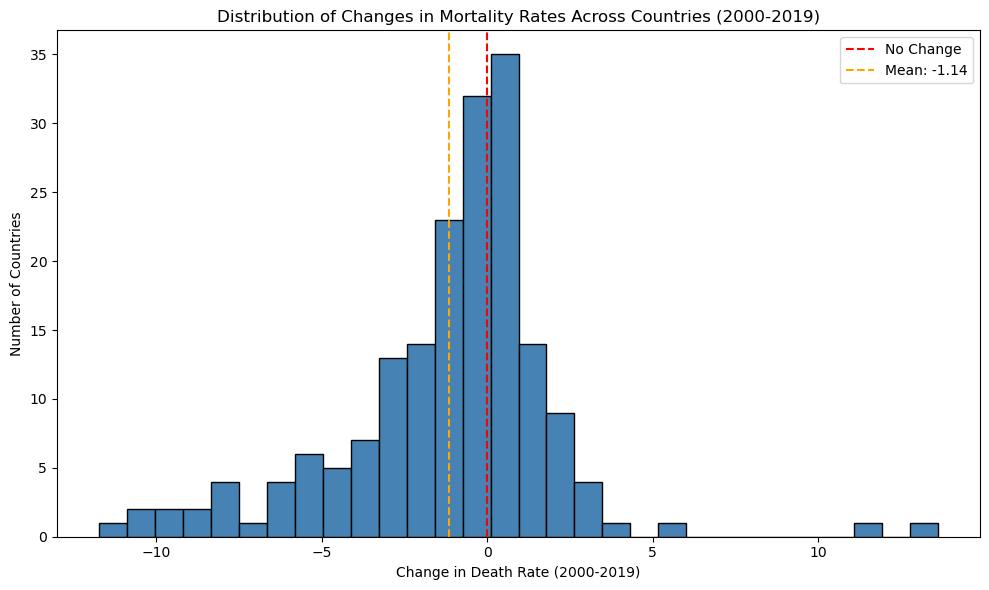

In [5]:
# ── 1. HISTOGRAM OF DEATH_CHANGE ──────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(df["death_change"], bins=30, color="steelblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--", label="No Change")
plt.axvline(df["death_change"].mean(), color="orange", linestyle="--",
            label=f"Mean: {df['death_change'].mean():.2f}")
plt.xlabel("Change in Death Rate (2000-2019)")
plt.ylabel("Number of Countries")
plt.title("Distribution of Changes in Mortality Rates Across Countries (2000-2019)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
print(f"Mean: {df['death_change'].mean():.3f}")
print(f"Variance: {df['death_change'].var():.3f}")
print(f"Standard Deviation: {df['death_change'].std():.3f}")
print(f"Skew: {df['death_change'].skew():.3f}")
print(f"Kurtosis: {df['death_change'].kurt():.3f}")
print(f"Min: {df['death_change'].min():.3f}")
print(f"Max: {df['death_change'].max():.3f}")

Mean: -1.143
Variance: 10.656
Standard Deviation: 3.264
Skew: -0.191
Kurtosis: 3.830
Min: -11.721
Max: 13.618


In [7]:
Q1 = df["death_change"].quantile(0.25)
Q3 = df["death_change"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["death_change"] < lower) | (df["death_change"] > upper)]
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
print(f"Number of outliers: {len(outliers)}")
print(outliers[["country_code", "region", "death_change"]])

Q1: -2.52, Q3: 0.59, IQR: 3.11
Lower bound: -7.18, Upper bound: 5.26
Number of outliers: 14
    country_code  region  death_change
3            AGO  Africa       -10.379
20           BIH  Europe         5.689
26           BDI  Africa        -8.460
31           CAF  Africa        13.618
55           ETH  Africa        -8.200
68           GNB  Africa        -7.906
98           MWI  Africa       -11.721
109          MCO  Europe        11.254
112          MOZ  Africa        -7.586
120          NER  Africa        -8.127
137          RWA  Africa        -9.041
145          SLE  Africa       -10.618
171          UGA  Africa        -9.366
181          ZMB  Africa        -9.716


In [8]:
# ── DESCRIPTIVE STATS + OUTLIERS FOR df_levels (death_rate by year) ───────────
def get_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, Q1, Q3, IQR

def describe_series(series, label, df_source, id_col="country_code"):
    lower, upper, Q1, Q3, IQR = get_bounds(series)
    outliers = df_source[(series < lower) | (series > upper)][[id_col, series.name]]

    print(f"─── {label} ───────────────────────────────")
    print(f"  Mean:        {series.mean():.3f}")
    print(f"  Median:      {series.median():.3f}")
    print(f"  Variance:    {series.var():.3f}")
    print(f"  Std Dev:     {series.std():.3f}")
    print(f"  Skew:        {series.skew():.3f}")
    print(f"  Kurtosis:    {series.kurt():.3f}  (excess, normal = 0)")
    print(f"  Min:         {series.min():.3f}")
    print(f"  Max:         {series.max():.3f}")
    print(f"  Q1:          {Q1:.3f}")
    print(f"  Q3:          {Q3:.3f}")
    print(f"  IQR:         {IQR:.3f}")
    print(f"  Lower Bound: {lower:.3f}")
    print(f"  Upper Bound: {upper:.3f}")
    print(f"  # Outliers:  {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Outlier countries:\n{outliers.to_string(index=False)}")
    print()


# Split df_levels by year before running stats
df_2000 = df_levels[df_levels["year"] == 2000]
df_2019 = df_levels[df_levels["year"] == 2019]

describe_series(df_2000["death_rate"], "Death Rate 2000", df_2000)
describe_series(df_2019["death_rate"], "Death Rate 2019", df_2019)

─── Death Rate 2000 ───────────────────────────────
  Mean:        9.027
  Median:      8.500
  Variance:    13.964
  Std Dev:     3.737
  Skew:        0.634
  Kurtosis:    -0.109  (excess, normal = 0)
  Min:         1.854
  Max:         20.008
  Q1:          6.361
  Q3:          10.879
  IQR:         4.518
  Lower Bound: -0.415
  Upper Bound: 17.655
  # Outliers:  5
  Outlier countries:
country_code  death_rate
         AGO      18.080
         TCD      17.852
         MWI      18.022
         NER      17.700
         SLE      20.008

─── Death Rate 2019 ───────────────────────────────
  Mean:        7.884
  Median:      7.408
  Variance:    11.257
  Std Dev:     3.355
  Skew:        2.216
  Kurtosis:    11.695  (excess, normal = 0)
  Min:         0.841
  Max:         30.250
  Q1:          6.087
  Q3:          9.332
  IQR:         3.245
  Lower Bound: 1.220
  Upper Bound: 14.198
  # Outliers:  7
  Outlier countries:
country_code  death_rate
         BGR      16.300
         CAF      3

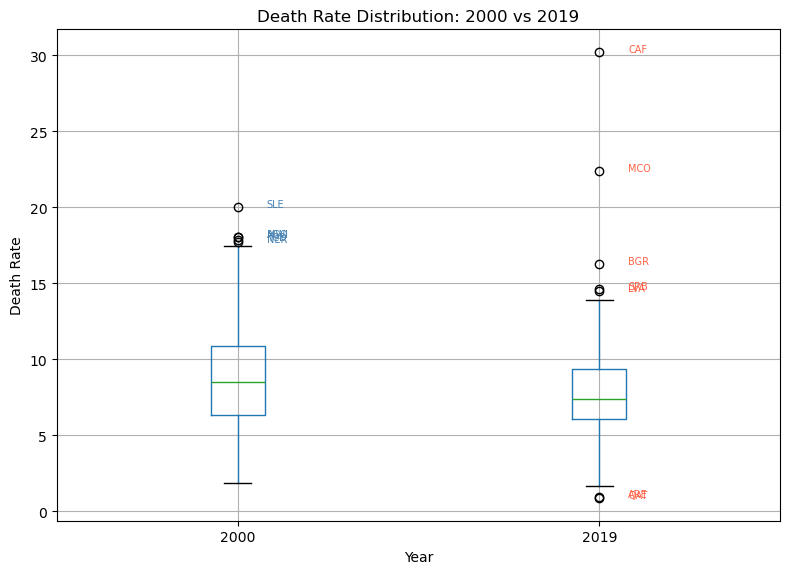

─── Death Rate Change (2000-2019) ───────────────────────────────
  Mean:        -1.143
  Median:      -0.523
  Variance:    10.656
  Std Dev:     3.264
  Skew:        -0.191
  Kurtosis:    3.830  (excess, normal = 0)
  Min:         -11.721
  Max:         13.618
  Q1:          -2.515
  Q3:          0.594
  IQR:         3.110
  Lower Bound: -7.180
  Upper Bound: 5.259
  # Outliers:  14
  Outlier countries:
country_code  death_change
         AGO       -10.379
         BIH         5.689
         BDI        -8.460
         CAF        13.618
         ETH        -8.200
         GNB        -7.906
         MWI       -11.721
         MCO        11.254
         MOZ        -7.586
         NER        -8.127
         RWA        -9.041
         SLE       -10.618
         UGA        -9.366
         ZMB        -9.716



In [9]:
# ── ANNOTATED BOX PLOT: DEATH RATE 2000 vs 2019 (df_levels) ──────────────────
lower_2000, upper_2000, _, _, _ = get_bounds(df_2000["death_rate"])
lower_2019, upper_2019, _, _, _ = get_bounds(df_2019["death_rate"])

outliers_2000 = df_2000[
    (df_2000["death_rate"] < lower_2000) | (df_2000["death_rate"] > upper_2000)
]
outliers_2019 = df_2019[
    (df_2019["death_rate"] < lower_2019) | (df_2019["death_rate"] > upper_2019)
]

fig, ax = plt.subplots(figsize=(8, 6))
df_levels.boxplot(column="death_rate", by="year", ax=ax)

for _, row in outliers_2000.iterrows():
    ax.annotate(row["country_code"],
                xy=(1, row["death_rate"]),
                xytext=(1.08, row["death_rate"]),
                fontsize=7, color="steelblue")

for _, row in outliers_2019.iterrows():
    ax.annotate(row["country_code"],
                xy=(2, row["death_rate"]),
                xytext=(2.08, row["death_rate"]),
                fontsize=7, color="tomato")

ax.set_title("Death Rate Distribution: 2000 vs 2019")
ax.set_xlabel("Year")
ax.set_ylabel("Death Rate")
plt.suptitle("")
plt.tight_layout()
plt.show()

# ── DESCRIPTIVE STATS + OUTLIERS FOR df_changes (death_change) ────────────────
describe_series(df_changes["death_change"], "Death Rate Change (2000-2019)",
                df_changes)


In [10]:
df["log_gdp_change"].describe()

count    182.000000
mean       1.067005
std        0.510267
min       -0.025493
25%        0.704655
50%        0.929222
75%        1.393697
max        2.367585
Name: log_gdp_change, dtype: float64

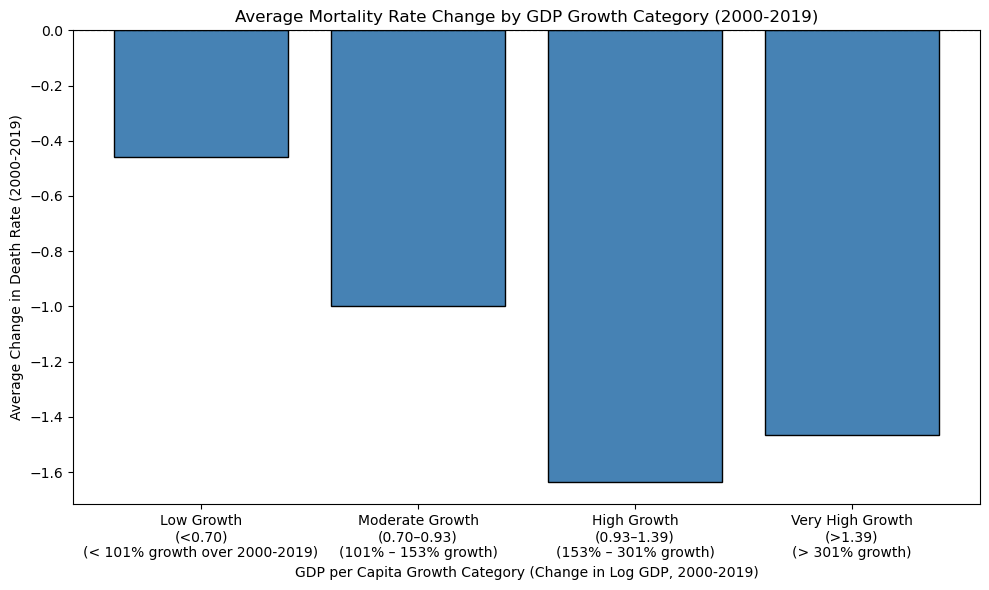

In [21]:
# ── 3. GROUPED BAR CHART — GDP GROWTH CATEGORIES ──────────────────────────────
df["gdp_group"] = pd.cut(
    df["log_gdp_change"],
    bins=[-np.inf, 0.70, 0.93, 1.39, np.inf],
    labels=["Low Growth\n(<0.70)\n(< 101% growth over 2000-2019)", "Moderate Growth\n(0.70–0.93)\n(101% – 153% growth)",
            "High Growth\n(0.93–1.39)\n(153% – 301% growth)", "Very High Growth\n(>1.39)\n(> 301% growth)"]
)

gdp_avg = df.groupby("gdp_group", observed=True)["death_change"].mean().reset_index()
colors = ["tomato" if x > 0 else "steelblue" for x in gdp_avg["death_change"]]

plt.figure(figsize=(10, 6))
plt.bar(gdp_avg["gdp_group"], gdp_avg["death_change"], color=colors, edgecolor="black")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("GDP per Capita Growth Category (Change in Log GDP, 2000-2019)")
plt.ylabel("Average Change in Death Rate (2000-2019)")
plt.title("Average Mortality Rate Change by GDP Growth Category (2000-2019)")
plt.tight_layout()
plt.show()

In [12]:
df["gdp_group"].value_counts().sort_index()

gdp_group
Low Growth\n(<0.70)             43
Moderate Growth\n(0.70–0.93)    49
High Growth\n(0.93–1.39)        44
Very High Growth\n(>1.39)       46
Name: count, dtype: int64

In [13]:
df["pop_65_change"].describe()

count    182.000000
mean       2.240358
std        2.360579
min       -0.930284
25%        0.413310
50%        1.903887
75%        3.591112
max       14.049646
Name: pop_65_change, dtype: float64

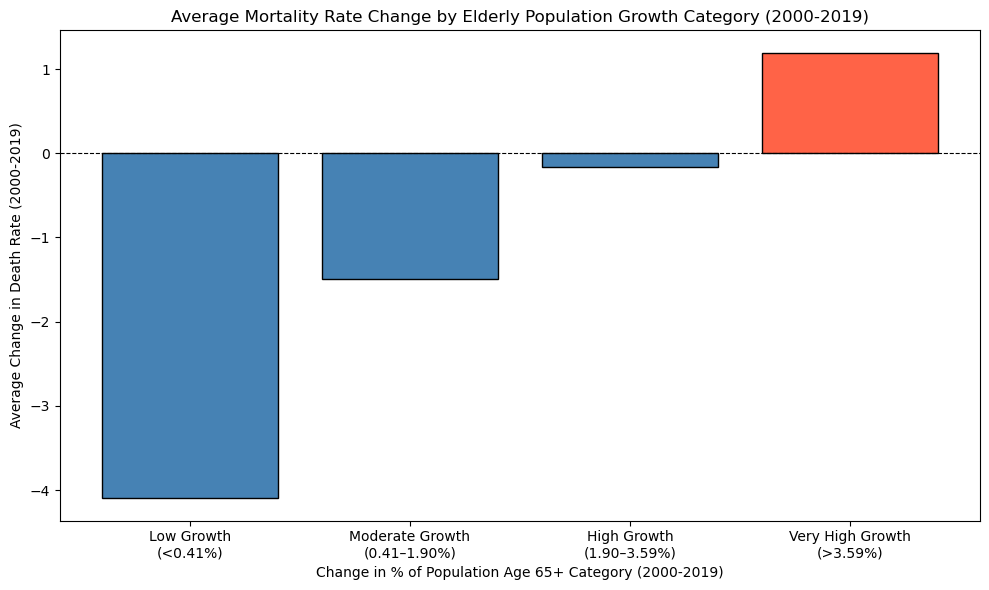

In [18]:
# ── 4. GROUPED BAR CHART — ELDERLY POPULATION GROWTH CATEGORIES ───────────────
df["pop_group"] = pd.cut(
    df["pop_65_change"],
    bins=[-np.inf,
          df["pop_65_change"].quantile(0.25),
          df["pop_65_change"].quantile(0.50),
          df["pop_65_change"].quantile(0.75),
          np.inf],
    labels=["Low Growth\n(<0.41%)",
            "Moderate Growth\n(0.41–1.90%)",
            "High Growth\n(1.90–3.59%)",
            "Very High Growth\n(>3.59%)"]
)

pop_avg = df.groupby("pop_group", observed=True)["death_change"].mean().reset_index()
colors = ["tomato" if x > 0 else "steelblue" for x in pop_avg["death_change"]]

plt.figure(figsize=(10, 6))
plt.bar(pop_avg["pop_group"], pop_avg["death_change"], color=colors, edgecolor="black")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Change in % of Population Age 65+ Category (2000-2019)")
plt.ylabel("Average Change in Death Rate (2000-2019)")
plt.title("Average Mortality Rate Change by Elderly Population Growth Category (2000-2019)")
plt.tight_layout()
plt.show()

In [19]:
#Verify group sizes
df["pop_group"].value_counts().sort_index()

pop_group
Low Growth\n(<0.41%)             46
Moderate Growth\n(0.41–1.90%)    45
High Growth\n(1.90–3.59%)        45
Very High Growth\n(>3.59%)       46
Name: count, dtype: int64

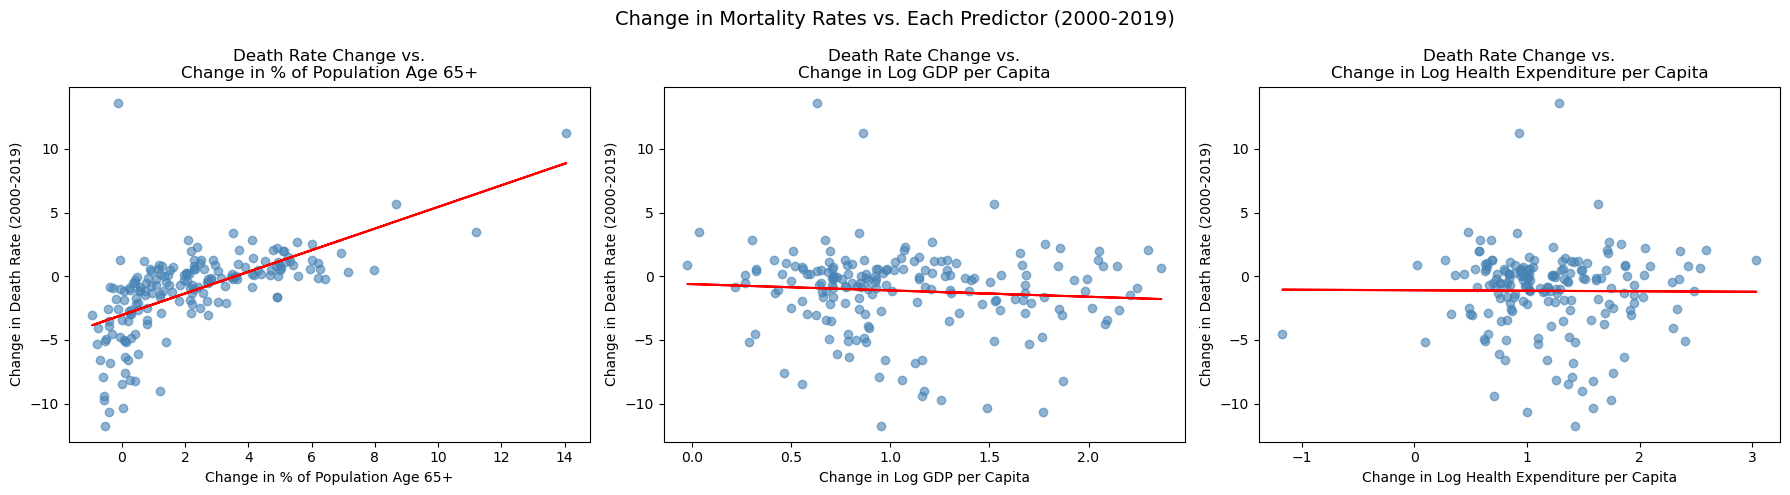

In [16]:
# ── 4. SCATTERPLOTS ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Change in Mortality Rates vs. Each Predictor (2000-2019)", fontsize=14)

predictors = [
    ("pop_65_change", "Change in % of Population Age 65+"),
    ("log_gdp_change", "Change in Log GDP per Capita"),
    ("log_health_change", "Change in Log Health Expenditure per Capita")
]

for ax, (col, label) in zip(axes, predictors):
    x = df[col]
    y = df["death_change"]
    m, b = np.polyfit(x, y, 1)
    ax.scatter(x, y, alpha=0.6, color="steelblue")
    ax.plot(x, m * x + b, color="red")
    ax.set_xlabel(label)
    ax.set_ylabel("Change in Death Rate (2000-2019)")
    ax.set_title(f"Death Rate Change vs.\n{label}")

plt.tight_layout()
plt.show()


In [20]:
df[df["region"] == "Unknown"]["country_code"].tolist()

[]